# ARIMA — Sales Forecasting (AirPassengers / fallback seasonal generator)

Time series EDA, stationarity checks, baselines, ARIMA selection, and backtesting.
Dataset: statsmodels built-in airline passengers (real) or a deterministic seasonal generator as fallback.

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Load time series

Source: generated (fallback): AttributeError("module 'statsmodels.datasets' has no attribute 'airline'")


2016-01-01    101.828302
2016-02-01    103.936566
2016-03-01    122.444106
2016-04-01    127.172800
2016-05-01    108.588128
Freq: MS, dtype: float64

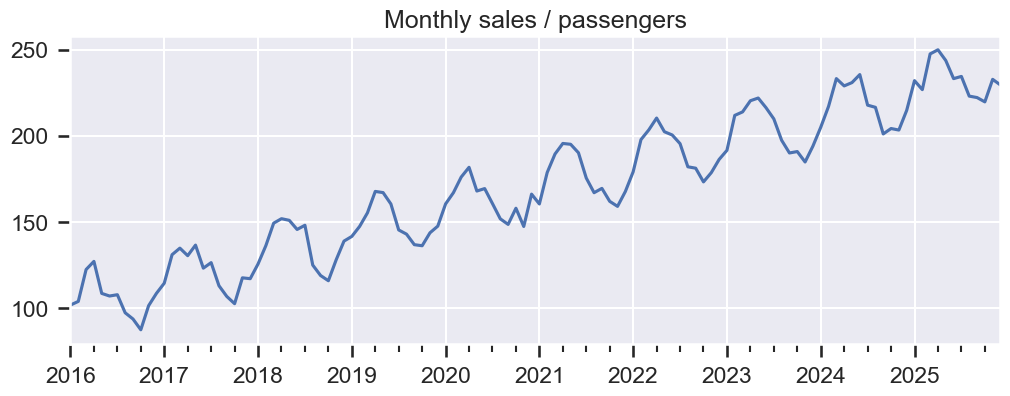

In [2]:
import numpy as np
import pandas as pd

# Try built-in AirPassengers via statsmodels, otherwise generate a realistic seasonal series
try:
    import statsmodels.api as sm
    d = sm.datasets.airline.load_pandas().data
    # statsmodels uses 'month' and 'passengers' columns
    d['month'] = pd.to_datetime(d['month'])
    ts = d.set_index('month')['passengers'].asfreq('MS')
    source = 'statsmodels.datasets.airline'
except Exception as e:
    rng = np.random.default_rng(SEED)
    idx = pd.date_range('2016-01-01', periods=120, freq='MS')
    trend = np.linspace(100, 240, len(idx))
    season = 18*np.sin(2*np.pi*np.arange(len(idx))/12)
    noise = rng.normal(0, 6, len(idx))
    ts = pd.Series(trend + season + noise, index=idx)
    source = f'generated (fallback): {repr(e)}'

print('Source:', source)
display(ts.head())

plt.figure(figsize=(12,4))
ts.plot()
plt.title('Monthly sales / passengers')
plt.show()


## EDA + decomposition

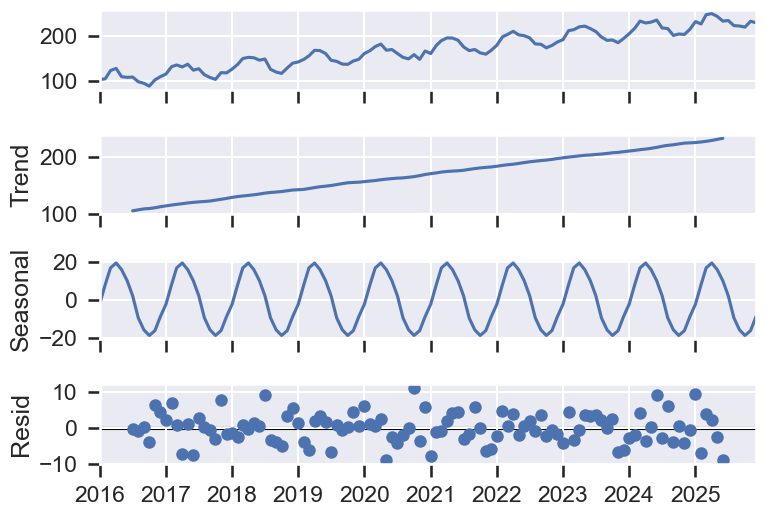

In [3]:
import statsmodels.api as sm

decomp = sm.tsa.seasonal_decompose(ts, model='additive', period=12)
decomp.plot()
plt.show()


## Train/test split + baselines

naive: {'mae': 18.133521063649905, 'rmse': 20.42313146324952}
seasonal_naive: {'mae': 29.34208858046954, 'rmse': 30.71580666380758}


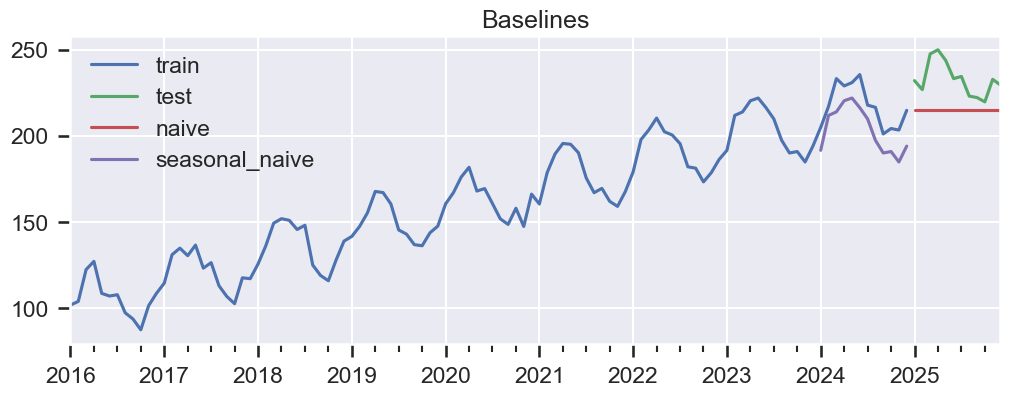

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

h = 12
train = ts.iloc[:-h]
test = ts.iloc[-h:]

# Naive baseline (last value)
naive = pd.Series([train.iloc[-1]]*h, index=test.index)
# Seasonal naive baseline
seasonal_naive = train.shift(12).iloc[-h:]

def metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': (mean_squared_error(y_true, y_pred) ** 0.5),
    }

print('naive:', metrics(test, naive))
print('seasonal_naive:', metrics(test, seasonal_naive))

plt.figure(figsize=(12,4))
train.plot(label='train')
test.plot(label='test')
naive.plot(label='naive')
seasonal_naive.plot(label='seasonal_naive')
plt.legend()
plt.title('Baselines')
plt.show()


## ARIMA model selection

Pick an ARIMA order using AIC as a lightweight selection criterion.

Best order by AIC: (2, 1, 3) AIC= 699.3222583057752
ARIMA: {'mae': 10.001043108442905, 'rmse': 12.072747091042864}


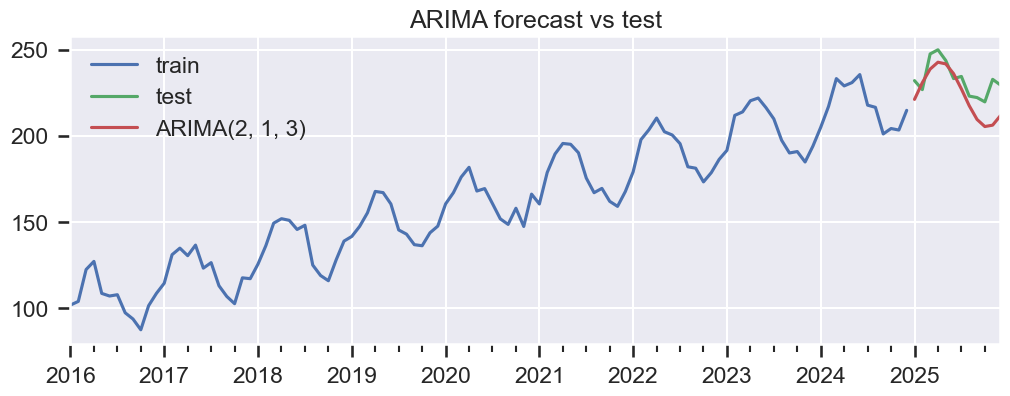

In [5]:
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm

# Small grid search on (p,d,q) for demonstration
candidates = []
for p in range(0, 4):
    for d in range(0, 3):
        for q in range(0, 4):
            try:
                m = sm.tsa.arima.ARIMA(train, order=(p,d,q))
                r = m.fit()
                candidates.append(((p,d,q), r.aic))
            except Exception:
                pass

best_order, best_aic = sorted(candidates, key=lambda x: x[1])[0]
print('Best order by AIC:', best_order, 'AIC=', best_aic)

model = sm.tsa.arima.ARIMA(train, order=best_order).fit()
fc = model.forecast(steps=h)

print('ARIMA:', metrics(test, fc))

plt.figure(figsize=(12,4))
train.plot(label='train')
test.plot(label='test')
fc.plot(label=f'ARIMA{best_order}')
plt.legend()
plt.title('ARIMA forecast vs test')
plt.show()


## Backtesting (rolling-origin)

Simulate realistic forecasting by training on past data and predicting the future repeatedly.

,cutoff,mae,rmse
count,8,8.000000,8.000000
mean,2022-10-01 03:00:00,11.197514,12.474201
min,2021-01-01 00:00:00,5.959671,8.214614
25%,2021-11-16 00:00:00,8.471100,9.483717
50%,2022-10-01 00:00:00,10.278566,11.827309
75%,2023-08-16 00:00:00,13.898555,14.785187
max,2024-07-01 00:00:00,17.339492,18.228397
std,NaN,4.024985,3.845436


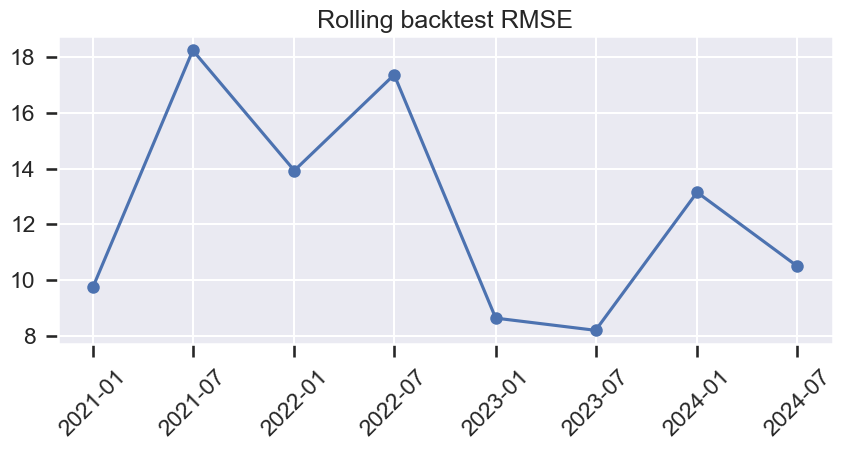

In [6]:
import numpy as np
import statsmodels.api as sm

def rolling_backtest(series, horizon=12, start=60, step=6, order=(1,1,1)):
    maes = []
    rmses = []
    cutoffs = []
    for end in range(start, len(series)-horizon, step):
        tr = series.iloc[:end]
        te = series.iloc[end:end+horizon]
        try:
            m = sm.tsa.arima.ARIMA(tr, order=order).fit()
            pred = m.forecast(steps=horizon)
            maes.append(np.mean(np.abs(te - pred)))
            rmses.append(np.sqrt(np.mean((te - pred)**2)))
            cutoffs.append(te.index[0])
        except Exception:
            continue
    return pd.DataFrame({'cutoff': cutoffs, 'mae': maes, 'rmse': rmses})

bt = rolling_backtest(ts, order=best_order)
display(bt.describe())

plt.figure(figsize=(10,4))
plt.plot(bt['cutoff'], bt['rmse'], marker='o')
plt.title('Rolling backtest RMSE')
plt.xticks(rotation=45)
plt.show()
